In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["LOKY_MAX_CPU_COUNT"] = "8"


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv("Dataset\smartcart_customers.csv")

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

# data-preprocessing


In [6]:
# handling missing values

from sklearn.impute import SimpleImputer

si = SimpleImputer(strategy = "median")
df[["Income"]] = si.fit_transform(df[["Income"]])

In [7]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# feature Engineering

In [8]:
# age

ref = df["Year_Birth"].max()

df["Age"] = ref - df["Year_Birth"]

In [9]:
# customer-tenure
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"] , dayfirst = True)

ref = df["Dt_Customer"].max()

df["Customer_tenure_days"] = (ref - df["Dt_Customer"]).dt.days

In [10]:
# total-spending

df["Total_Spending"] = df["MntWines"] +  df["MntFruits"] +  df["MntMeatProducts"] +  df["MntFishProducts"] +  df["MntSweetProducts"] +  df["MntGoldProds"]

In [11]:
# total-chlideran

df["Total_childes"] = df["Kidhome"] + df["Teenhome"]

In [12]:
# Education
df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic" : "Undergraduate" , "2n Cycle" : "Undergraduate",
    "Graduation" : "Graduate" ,
    "PhD" : "PostGraduate" , "Master" : "PostGraduate"
})

In [13]:
# Marital-status
df["Marital_Status"].value_counts()

df["Living_Status"] = df["Marital_Status"].replace({
    "Married":"Partner" , "Together":"Partner",
    "Single":"Alone" , "Divorced":"Alone" ,
    "Widow":"Alone" , "Absurd":"Alone" , "YOLO":"Alone"
})

In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_childes,Living_Status
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,39,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,42,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,31,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,12,139,53,1,Partner
4,5324,1981,PostGraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,15,161,422,1,Partner


# droping Columns

In [15]:
cols = ["ID" , "Year_Birth" , "Marital_Status" , "Kidhome" ,"Teenhome" , "Dt_Customer"]

products = ["MntWines" , "MntFruits" , "MntMeatProducts" , "MntFishProducts" , "MntSweetProducts" , "MntGoldProds"]

df = df.drop(columns=cols , axis = 1)
df_cleaned = df.drop(columns=products , axis = 1)

In [16]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_childes,Living_Status
0,Graduate,58138.0,58,3,8,10,4,7,0,1,39,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,42,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,31,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,12,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,15,161,422,1,Partner


In [17]:
df_cleaned.shape

(2240, 15)

# Outlier

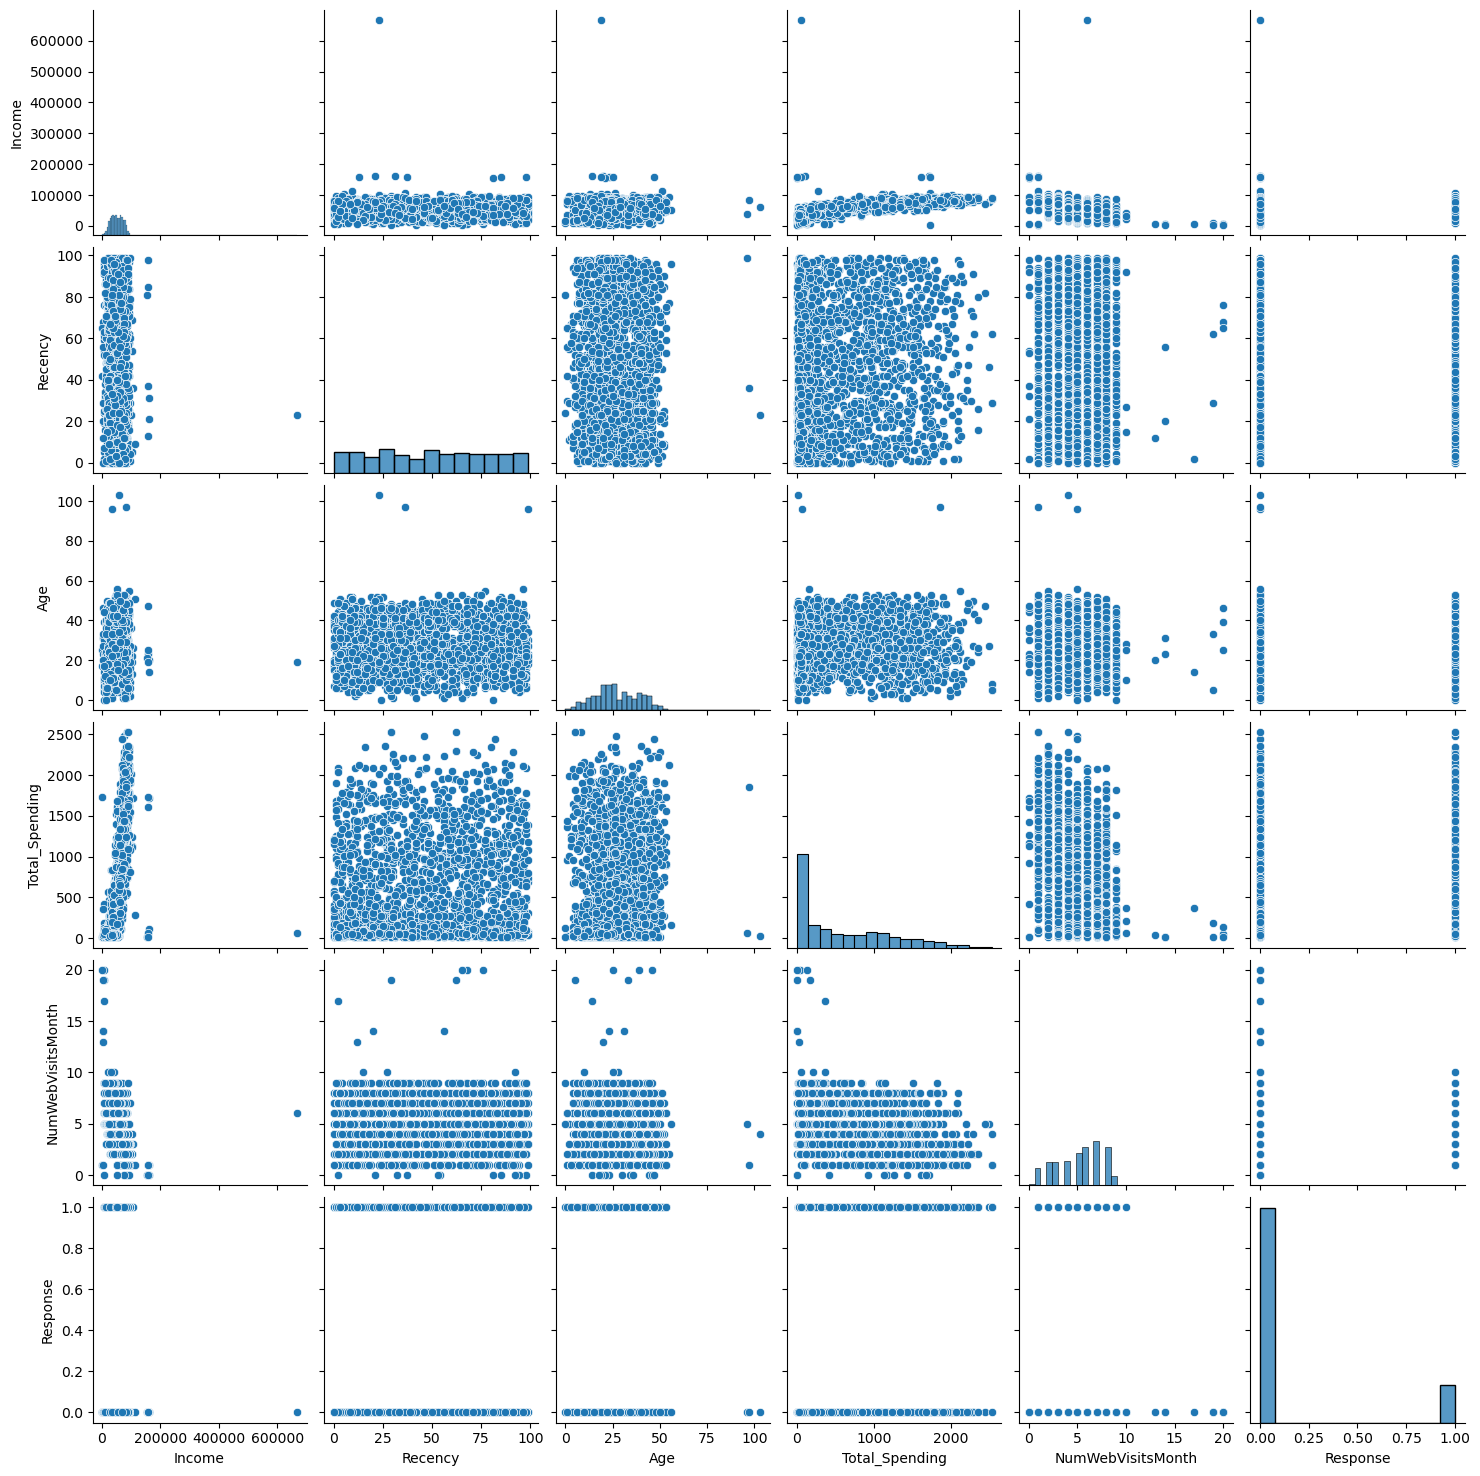

In [18]:
# outlier-detecton
col =["Income" , "Recency" , "Age" , "Total_Spending" , "NumWebVisitsMonth" , "Response"]

sns.pairplot(df_cleaned[col])

In [19]:
# removing Outlier
print("No of customers with outlier : " , len(df_cleaned))

df_cleaned = df_cleaned[ df_cleaned["Age"] < 90 ]
df_cleaned = df_cleaned[ df_cleaned["Income"] < 600000 ]

print("No of customers after removing outlier : " , len(df_cleaned))

No of customers with outlier :  2240
No of customers after removing outlier :  2236


# Encoding

In [20]:
# one hot encoding
from sklearn.preprocessing import OneHotEncoder
cols = ["Education" , "Living_Status"]
ohe = OneHotEncoder( sparse_output = False , handle_unknown = "ignore")
encoding = ohe.fit_transform(df_cleaned[cols])

In [21]:
df_encoded = pd.DataFrame(encoding , columns=ohe.get_feature_names_out(cols) , index = df_cleaned.index)

In [22]:
df_encoded.head()

,Education_Graduate,Education_PostGraduate,Education_Undergraduate,Living_Status_Alone,Living_Status_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [23]:
df_final = pd.concat([df_cleaned.drop(columns = cols) , df_encoded] , axis = 1)

In [24]:
df_final.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_childes,Education_Graduate,Education_PostGraduate,Education_Undergraduate,Living_Status_Alone,Living_Status_Partner
0,58138.0,58,3,8,10,4,7,0,1,39,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,42,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,31,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,12,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,15,161,422,1,0.0,1.0,0.0,0.0,1.0


# scaling


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_final)

In [26]:
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]])

# heatmap

In [27]:
corr = df_final.corr(numeric_only = True)

<Axes: >

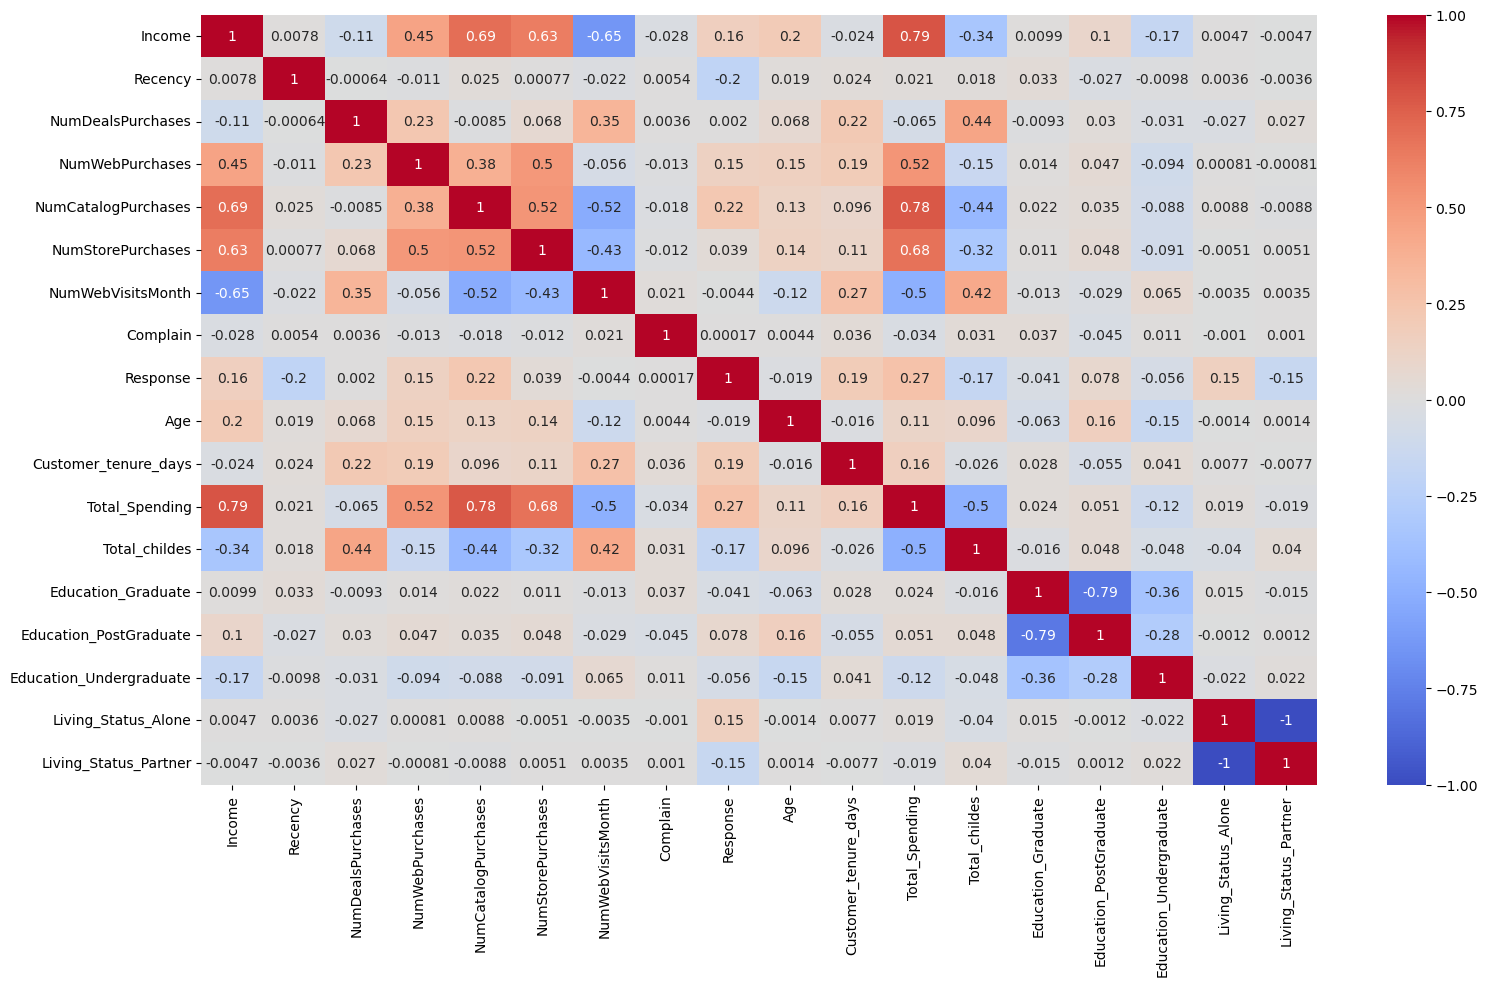

In [28]:
plt.figure(figsize = (18,10))

sns.heatmap(
    corr,
    annot = True,
    cmap = "coolwarm"
)

# Visualize

In [29]:
from sklearn.decomposition import PCA

pca = PCA( n_components = 3 , random_state = 42)
X_pca = pca.fit_transform(X_scaled)

<Axes: >

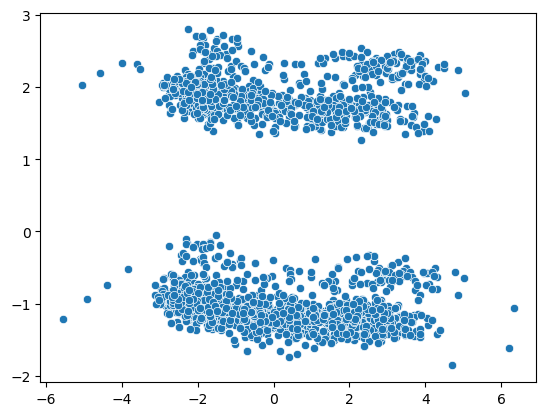

In [30]:
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1]
)

In [31]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

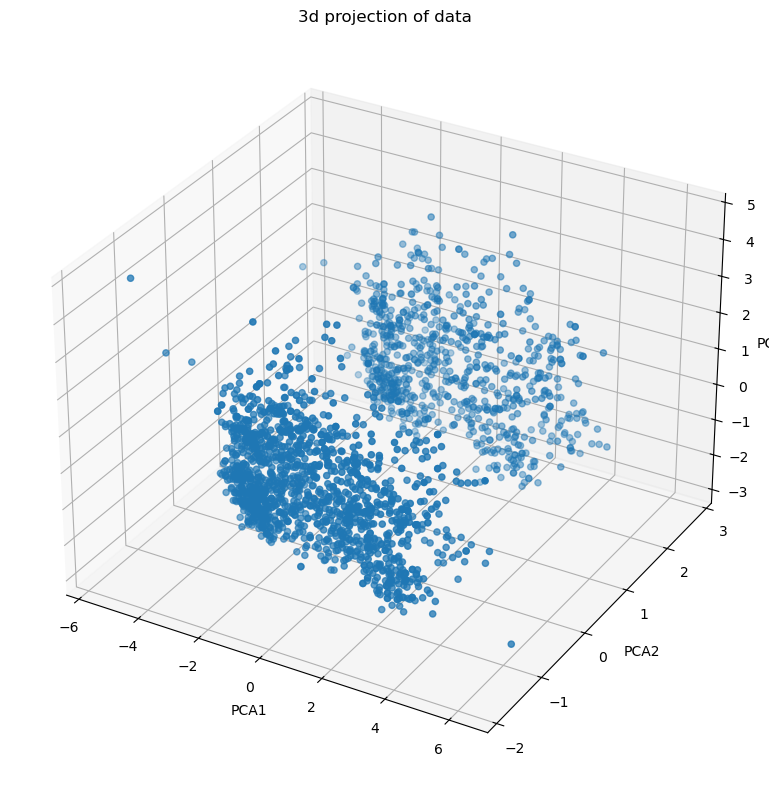

In [32]:
fig = plt.figure(figsize = (10,8))

ax = fig.add_subplot(111 , projection="3d")

ax.scatter(X_pca[:,0] , X_pca[:,1] , X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection of data")
fig.tight_layout()

# optimal value of k
## 1.Elbow Method

In [33]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmean = KMeans(n_clusters = k , random_state = 42)
    kmean.fit_predict(X_pca)
    wcss.append(kmean.inertia_)

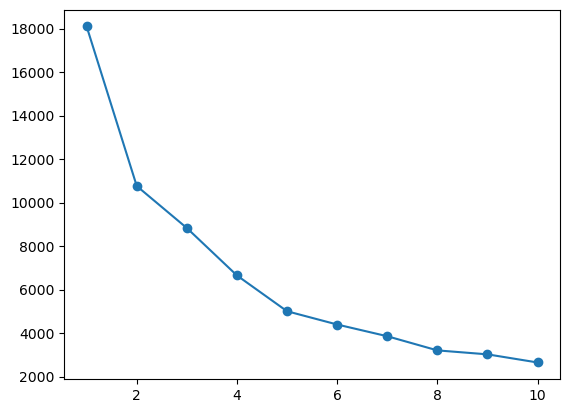

In [34]:
plt.plot(range(1,11) , wcss , marker="o")

## 2.SS

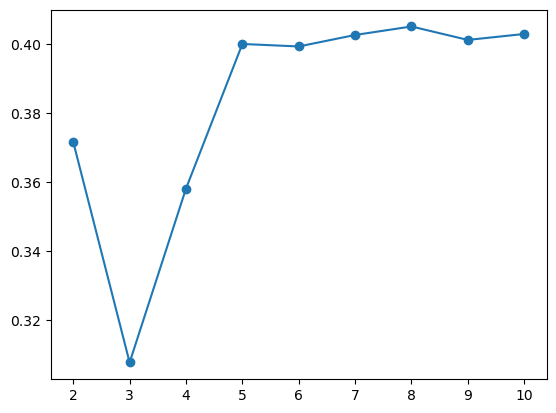

In [35]:
from sklearn.metrics import silhouette_score

scores =[]
for k in range(2,11):
    kmean=KMeans(n_clusters = k , random_state = 42)
    label = kmean.fit_predict(X_pca)
    scores.append(silhouette_score(X_pca , label))


plt.plot(range(2,11) , scores , marker="o")

Text(0, 0.5, 'SS')

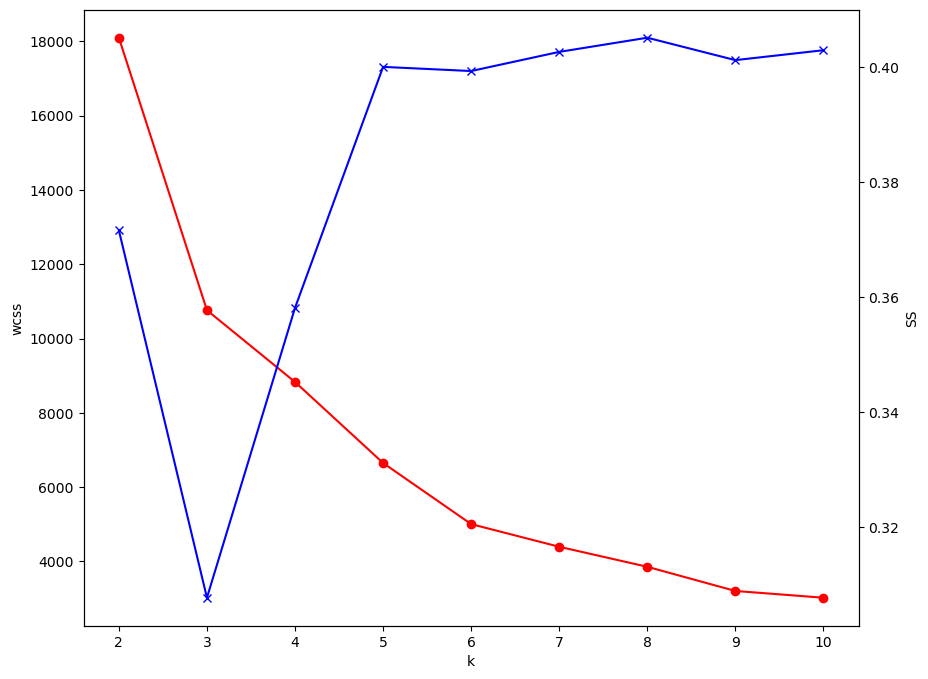

In [36]:
# mixplot 

fig = plt.figure(figsize = (10 , 8))

ax = fig.subplots()
ax1 = ax.plot(range(2,11) , wcss[:len(range(2,11))] , marker = "o" , color="red")
ax.set_xlabel("k")
ax.set_ylabel("wcss")

ax2 = ax.twinx()
ax2.plot(range(2,11) , scores[:len(range(2,11))] , marker = "x" , color="blue")
ax2.set_ylabel("SS")

# clustering Algo..

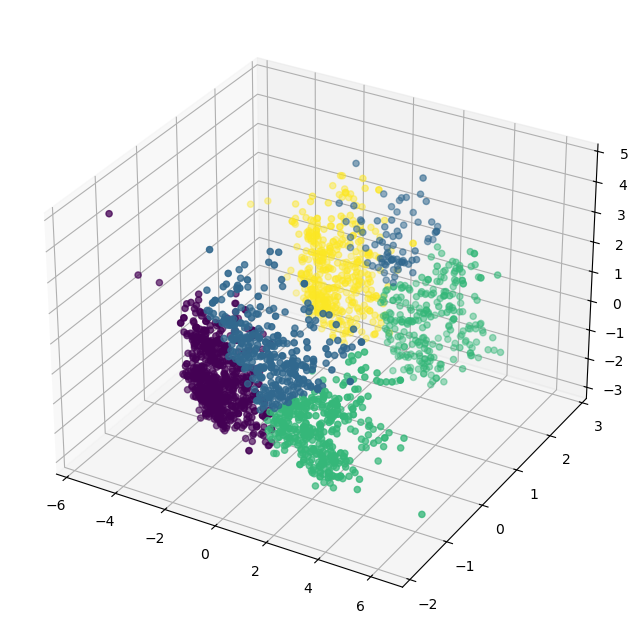

In [37]:
kmean = KMeans(n_clusters = 4 , random_state = 42)
label = kmean.fit_predict(X_pca)

fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot(111 , projection= "3d")
ax.scatter(X_pca[:,0] , X_pca[:,1] , X_pca[:,2] , c=label)

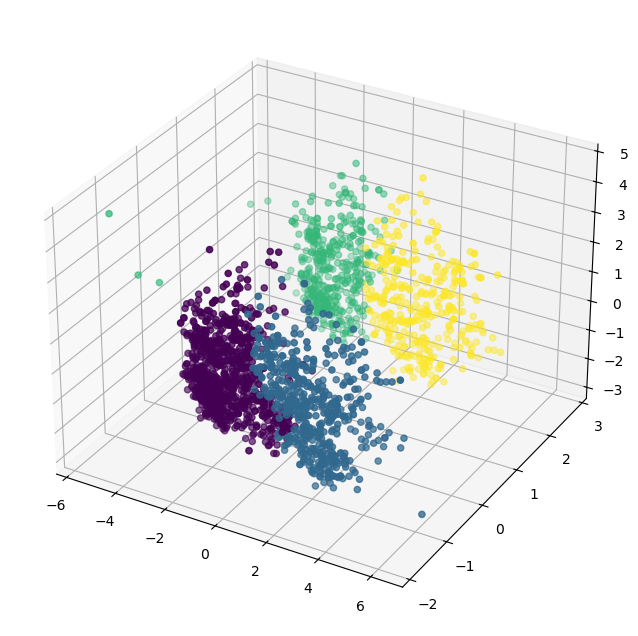

In [39]:
# agglomeratve
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters = 4 , linkage= "ward")
agg_label = agg.fit_predict(X_pca)

fig = plt.figure(figsize = (10, 8))
ax = fig.add_subplot(111 , projection= "3d")
ax.scatter(X_pca[:,0] , X_pca[:,1] , X_pca[:,2] , c=agg_label)

In [45]:
df_final.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_Spending,Total_childes,Education_Graduate,Education_PostGraduate,Education_Undergraduate,Living_Status_Alone,Living_Status_Partner
0,58138.0,58,3,8,10,4,7,0,1,39,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,42,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,31,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,12,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,15,161,422,1,0.0,1.0,0.0,0.0,1.0


In [46]:
df_final["cluster"] = agg_label

<Axes: xlabel='cluster', ylabel='count'>

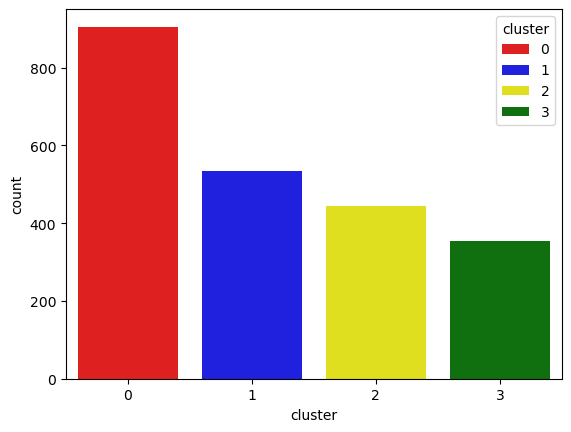

In [47]:
pl = ["red" , "blue" , "yellow" , "green"]

sns.countplot(x = df_final["cluster"] , palette = pl , hue= df_final["cluster"])

<Axes: xlabel='Income', ylabel='Total_Spending'>

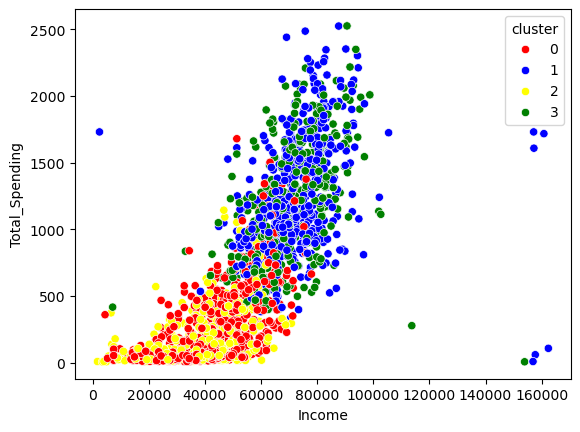

In [48]:
sns.scatterplot(x = df_final["Income"] , y = df_final["Total_Spending"] , palette = pl , hue = df_final["cluster"])

In [49]:
cluster_summary = df_final.groupby(df_final["cluster"]).mean()

print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_tenure_days  Total_Spending  \
cluster         